# Quickstart

A star-forming galaxy with 14 broadband fluxes from GALEX, SDSS, 2MASS,
and WISE (UV through mid-IR), fitted with NUTS on a differentiable JAX
forward model.

Truncated-skew-normal SFH, two-component Calzetti dust with modified-
blackbody IR re-emission, nebular off, redshift fixed at 0.05. Seven free
parameters. See `04_building_models.py` for the recipe grammar and
`02_sed_anatomy.py` for a panchromatic model with nebular, AGN, and
IGM enabled.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    builders,
    citations,
    cosmology,
    generate_mock,
    load_ssp_data,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

W0524 12:35:18.955811 3176945 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0524 12:35:20.147794 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.150445 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Stellar library and observation

A bare-stellar SSP grid (Cue-compatible if you later want to add nebular
emission). `download_ssp` fetches on first use.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
    "wise_w3",
    "wise_w4",
]
obs = Observation(photometry=Photometry.from_names(FILTERS))

SSP file already exists at data/fsps_prsc_miles_chabrier.h5; skipping download.


W0524 12:35:20.492525 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Build the model

A truncated skew-normal SFH, two-component Calzetti dust with a
modified-blackbody IR re-emission (so the WISE mid-IR bands carry signal),
nebular emission off, redshift fixed at z = 0.05. Seven free
parameters. `model.summary()` prints the assembled pipeline;
`citations.print_citations` pulls the bibliography straight from the
registry — enough for a methods section.

In [3]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh=builders.sfh.tsnorm(defaults=FREE),
    dust=builders.dust.two_component(
        defaults=FIXED,
        law_bc="calzetti",
        tau_bc=Uniform(0.0, 1.0),
        emission=builders.dust.emission.modified_blackbody(defaults=FIXED),
    ),
    neb=builders.neb.none(),
    redshift=Fixed(0.05),
)
forward = ForwardModel.build(sed=sed_model, observation=obs)

print(sed_model.summary())
citations.print_citations(sed_model)

W0524 12:35:20.665677 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.668745 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.687282 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.689951 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:20.697811 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.701211 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.704921 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.715637 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:972: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular 

W0524 12:35:20.909965 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.980487 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.984065 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.987135 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:20.990160 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.002711 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.079663 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:21.182910 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.330563 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.359616 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:21.613338 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.616683 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:21.658641 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:21.832760 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:22.169714 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.211944 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.260535 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Model  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     14 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Precomputed: photometry
  Components:  dust_emission=modified_blackbody, igm

  Pipeline (4 components):
    1. stellar        [sfh_model=tsnorm, metallicity_model=delta, n_grid=64]
    2. nebular        [backend=baked_in]
    3. dust           [law_bc=calzetti, law_diff=calzetti, emission_model=modified_blackbody]
    4. igm

  Parameters:  7 free
──────────────────────────────────────────────────────────────────
Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA com

## Mock observation

One draw from the prior is the truth. `generate_mock` returns the
noiseless model fluxes, Gaussian uncertainties at the requested SNR,
and a noisy realisation.

In [4]:
key = jax.random.PRNGKey(7)
key_truth, key_mock, key_fit = jax.random.split(key, 3)

truth = sed_model.spec.sample(key_truth)
mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = (
    np.array(
        [
            np.trapezoid(w * t, w) / np.trapezoid(t, w)
            for w, t in zip(phot.filter_waves, phot.filter_trans)
        ]
    )
    / 1e4
)

W0524 12:35:22.598066 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.609976 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.637336 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.669824 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:22.958782 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.988706 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.995084 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:22.998510 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:23.036980 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:23.039604 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:23.060377 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:23.080287 3176757 pjrt_executable.cc:638] Assume v

## One-time JIT compile

First touch of the photometric forward kernel and its gradient triggers
XLA compilation against the precomputed SSP × filter LUT (the
`WavePrecomp` knob set above). Cold cache is a few seconds; warm cache
(`~/.cache/tengri_jax_cache`) is milliseconds. Subsequent calls are
pure numeric throughput — no Python in the hot path.

In [5]:
import time

p0 = {**sed_model.spec.get_fixed_values(), **truth}
predict_phot = jax.jit(sed_model.predict_photometry)
grad_fn = jax.jit(
    jax.grad(lambda p: 0.5 * jnp.sum(((sed_model.predict_photometry(p) - flux_obs) / noise) ** 2))
)

t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   warm:       {time.perf_counter() - t:8.4f} s")

t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  warm:       {time.perf_counter() - t:8.4f} s")

W0524 12:35:23.184498 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  forward kernel   first call:   0.0788 s  (compile + run)
  forward kernel   warm:         0.0002 s


  ∇log-likelihood  first call:   0.4773 s  (compile + run)
  ∇log-likelihood  warm:         0.0003 s


W0524 12:35:23.637677 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Pre-warm

`Fitter.prewarm` compiles the loss / sampler stack and runs the NUTS
window adaptation once. After this call the model carries a cached
step size, mass matrix, and MAP point estimate. Subsequent `.run()`
calls skip both the XLA compile and the warmup; only the actual
sampling work remains.

*Note*: routing through `Fitter(sed_model, ...)` instead of
`forward.fit(...)` is a temporary workaround for issue #281
(`ForwardModel.predict` bypasses the WavePrecomp LUT, ~16× slowdown).
Will be removed once #281 closes.

In [6]:
from tengri.inference.fitter import Fitter

fitter = Fitter(sed_model, flux_obs, noise, data_type="photometry")
t = time.perf_counter()
fitter.prewarm(method="mcmc_nuts", n_chains=4)
print(f"  prewarm wall: {time.perf_counter() - t:6.2f} s")

# Optional: persist the cache to disk. A fresh notebook session can then
# `fitter.load_cache(...)` and skip warmup + MAP init entirely.
# fitter.save_cache("00_quickstart_cache.pkl")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_76446/78365321.py:3: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(sed_model, flux_obs, noise, data_type="photometry")


W0524 12:35:24.568972 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.597584 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.602650 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.612685 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.617578 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.634242 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:24.639116 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:24.989629 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:25.125151 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:25.176261 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:25.190191 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:25.295019 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:25.821255 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0524 12:35:30.281501 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.286377 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.297476 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.327861 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.342628 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.383278 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:30.869888 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:30.974180 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:31.013331 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:31.449339 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:31.548824 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  prewarm wall:  11.45 s


W0524 12:35:35.100107 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Fit

MAP (ADAM) for the point estimate; NUTS with four parallel chains via
`jax.vmap` for the full posterior. Both calls reuse the prewarmed
adaptation cache.

In [7]:
t = time.perf_counter()
map_result = fitter.run(method="map", key=key_fit, n_steps=200)
print(f"  MAP wall:  {time.perf_counter() - t:6.2f} s")

t = time.perf_counter()
posterior = fitter.run(
    method="mcmc_nuts",
    key=key_fit,
    n_warmup=400,
    n_samples=400,
    n_chains=4,
    n_burnin=0,
)
print(f"  NUTS wall (4 chains × 400 = 1600 samples): {time.perf_counter() - t:6.2f} s")
posterior.summary()

W0524 12:35:35.255714 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:35.260830 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:35.277548 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:35.282990 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:35.733339 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:35.876659 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:35.929720 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


    step 200: loss=7.2572
  MAP (ADAM) complete in 0.2s, 200 steps, loss=7.2572
  MAP wall:    0.80 s
  MAP initialization: reusing cached MAP point


W0524 12:35:35.944803 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.125145 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.129884 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.140432 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:36.169364 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.183051 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.221999 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:36.719737 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.824992 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:36.865134 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:37.295744 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:37.393647 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  NUTS wall (4 chains × 400 = 1600 samples):  14.30 s
Posterior  method: NUTS (BlackJAX)  samples: 1600  wall_time: 14.1s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_T                         35.0000   35.0000   35.0000       —
  dust_T_cold                    20.0000   20.0000   20.0000       —
  dust_T_warm                    45.0000   45.0000   45.0000       —
  dust_alpha_dale                 2.0000    2.0000    2.0000       —
  dust_alpha_dl14                 2.0000    2.0000    2.0000       —
  dust_alpha_mir                  2.0000    2.0000    2.0000       —
  dust_beta_ir                    1.6000    1.6000    1.6000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    

Derived physical scalars — stellar mass, SFR, sSFR — rolled up from the
SFH integral, with the input truth in the first column.

In [8]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)
fixed = sed_model.spec.get_fixed_values()


def draw_dicts(n):
    for i in range(n):
        yield {**fixed, **{k: float(v[i]) for k, v in draws.items()}}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")
samples = {k: [] for k in DERIVED_KEYS}
for p in draw_dicts(N_DRAWS):
    d = sed_model.predict_derived(p)
    for k in DERIVED_KEYS:
        v = d.get(k)
        samples[k].append(float("nan") if v is None else float(v))

truth_full = {**fixed, **truth}
truth_derived = sed_model.predict_derived(truth_full)
print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = np.percentile(samples[k], [16, 50, 84])
    t = truth_derived.get(k)
    tstr = "—" if t is None else f"{float(t):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

W0524 12:35:50.263704 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.289359 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.459524 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.463757 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:50.467634 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.485425 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.499049 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.586681 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.635657 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:50.684088 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.702356 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.713999 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.730393 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.733601 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.736519 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.768655 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.799080 3176757 pjrt_executable.cc:638] Assume v

W0524 12:35:50.895054 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.898230 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.901893 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.904834 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.907624 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.910255 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.914614 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:50.969518 3176757 pjrt_executable.cc:638] Assume v

W0524 12:35:51.132700 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.166487 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.216640 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.271097 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.298937 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.301954 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.305598 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.328953 3176757 pjrt_executable.cc:638] Assume v

W0524 12:35:51.345273 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.348332 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.350901 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.354118 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.357806 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.360697 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.364070 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.367057 3176757 pjrt_executable.cc:638] Assume v

W0524 12:35:51.694980 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.710680 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.733817 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.773225 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.776910 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.779468 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.782263 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.799394 3176757 pjrt_executable.cc:638] Assume v

W0524 12:35:51.910366 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.913657 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.916468 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.937300 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.987304 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:51.990838 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:52.022012 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


quantity               truth           p16           p50           p84
----------------------------------------------------------------------
stellar_mass       1.265e+11     1.003e+11     1.106e+11     1.205e+11
sfr_100myr         1.077e+01     1.030e+01     1.112e+01     1.182e+01
sfr_10myr          1.076e+01     1.028e+01     1.110e+01     1.180e+01
ssfr               8.510e-11     9.042e-11     9.989e-11     1.136e-10


W0524 12:35:57.419700 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:57.546672 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:57.572691 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Posterior SED

Full posterior spectrum in the background (median + 68 % band), truth
dashed, observed photometry with error bars, residuals against the
posterior median below.

W0524 12:35:57.599570 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:59.370396 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:35:59.416088 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:35:59.756981 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:00.233926 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:00.472498 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:00.561633 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0524 12:36:02.672187 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:02.689430 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:05.350062 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:05.453111 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:05.462662 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:05.609031 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:05.696036 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:05.784775 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:05.889652 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:06.044161 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:06.133909 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:06.276916 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:06.280347 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


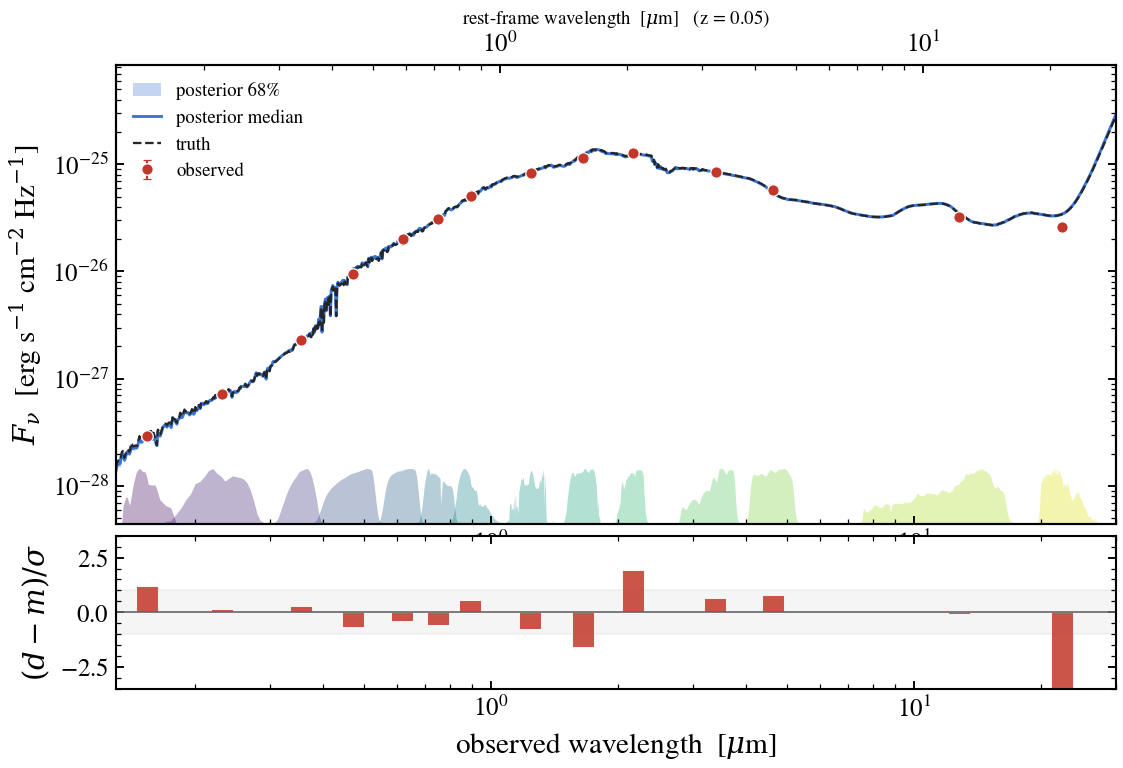

In [9]:
WAVE_OBS = np.geomspace(1300.0, 3e5, 1200)  # 0.13–30 μm covers GALEX → WISE W4
z_truth = float(truth_full["redshift"])
dl_cm = cosmology.luminosity_distance(z_truth)


def obs_fnu(params):
    rest = sed_model.predict_rest_sed(params, wave=WAVE_OBS / (1.0 + z_truth))
    return np.asarray(lnu_to_fnu(jnp.asarray(rest.sed), dl_cm, z_truth))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(60)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth_full)

phot_draws = np.asarray(jax.vmap(lambda p: forward.predict_observables(p)["phot_fnu"])(draws))
phot_med = np.median(phot_draws, axis=0)

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

wave_um = WAVE_OBS / 1e4

# Filter transmission curves shaded behind the spectrum — Bagpipes/Prospector
# style. Use the matplotlib default qualitative palette across bands.
band_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(phot.filter_waves)))
ymin, ymax = 0.3 * spec_truth.min(), 3 * spec_truth.max()
for fw, ft, color in zip(phot.filter_waves, phot.filter_trans, band_palette):
    fw_um = np.asarray(fw) / 1e4
    ft_norm = np.asarray(ft) / np.max(ft)
    # Map transmission to the bottom 12 % of the log-y axis.
    band = ymin * (ymax / ymin) ** (0.12 * ft_norm)
    ax.fill_between(fw_um, ymin, band, color=color, alpha=0.35, lw=0)

ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.4, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.1, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5.5,
    capsize=2,
    elinewidth=1.0,
    mec="white",
    mew=0.6,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(wave_um.min(), wave_um.max())
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)

# Rest-frame wavelength axis on top.
ax_rest = ax.twiny()
ax_rest.set_xscale("log")
ax_rest.set_xlim(wave_um.min() / (1.0 + z_truth), wave_um.max() / (1.0 + z_truth))
ax_rest.set_xlabel(rf"rest-frame wavelength  [$\mu$m]   (z = {z_truth:.2f})", fontsize=9)

resid = (flux_obs - phot_med) / noise
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(
    wave_eff_um,
    resid,
    width=wave_eff_um * 0.12,
    color=C_DATA,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax_res.set_xscale("log")
ax_res.set_xlim(wave_um.min(), wave_um.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "00_posterior_sed.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "00_posterior_sed.pdf", bbox_inches="tight")

## Star-formation history

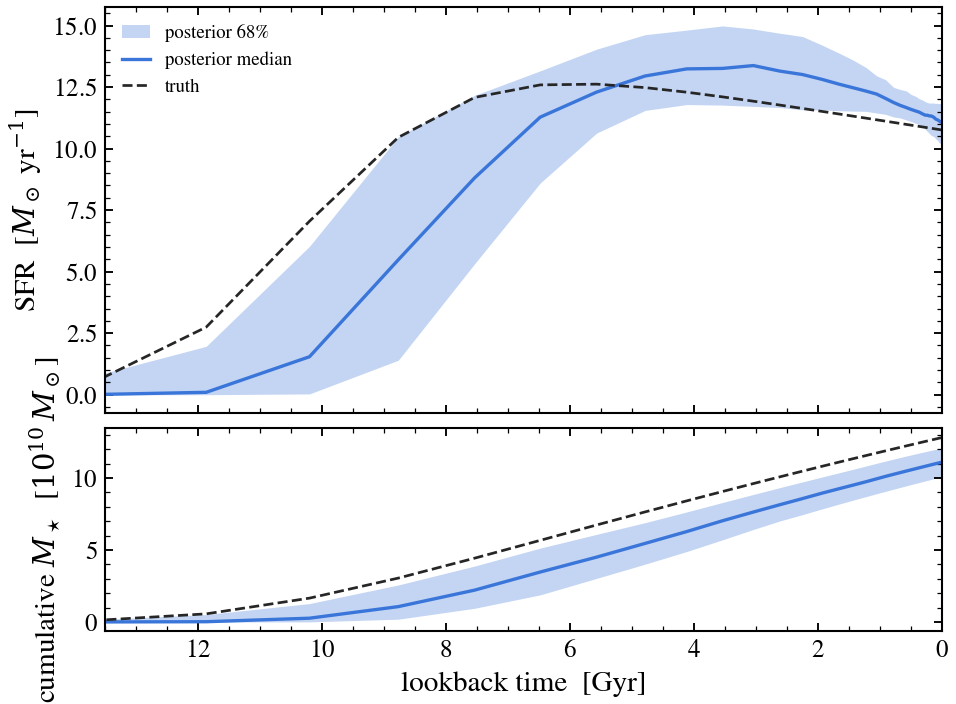

In [10]:
def sfh(p):
    s = sed_model.predict_state(p)
    return (
        np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
        np.asarray(s.derived["sfr_history"]),
    )


sfr_draws, lbt = [], None
for p in draw_dicts(120):
    lbt_i, sfr_i = sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
lbt_t, sfr_t = sfh(truth_full)

# Two-panel SFH: SFR(t) on top, cumulative formed mass on bottom.
fig_sfh, (ax_sfh, ax_cum) = plt.subplots(
    2, 1, figsize=(7.2, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.05)
)

ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_sfh.plot(lbt, sfr_med, color=C_POST, lw=1.6, label="posterior median")
ax_sfh.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.3, label="truth")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_sfh.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax_sfh.get_xticklabels(), visible=False)

# Cumulative formed stellar mass — integrate SFR(t) backwards from now.
dt_yr = np.gradient(lbt * 1e9)  # Gyr → yr, signed
cum_draws = np.flip(np.cumsum(np.flip(sfr_draws * dt_yr[None, :], axis=1), axis=1), axis=1)
cum_lo, cum_med, cum_hi = np.percentile(cum_draws, [16, 50, 84], axis=0)
cum_truth = np.flip(np.cumsum(np.flip(sfr_t * dt_yr), axis=0), axis=0)
ax_cum.fill_between(lbt, cum_lo / 1e10, cum_hi / 1e10, color=C_POST, alpha=0.30, lw=0)
ax_cum.plot(lbt, cum_med / 1e10, color=C_POST, lw=1.6)
ax_cum.plot(lbt_t, cum_truth / 1e10, color=C_TRUTH, ls="--", lw=1.3)
ax_cum.set_ylabel(r"cumulative $M_\star$  [$10^{10}\,M_\odot$]")

for axx in (ax_sfh, ax_cum):
    axx.invert_xaxis()
    axx.set_xlim(13.5, 0)
ax_cum.set_xlabel("lookback time  [Gyr]")

fig_sfh.savefig(FIG_DIR / "00_sfh.png", dpi=300, bbox_inches="tight")
fig_sfh.savefig(FIG_DIR / "00_sfh.pdf", bbox_inches="tight")

## Corner

Free parameters plus derived quantities (`stellar_mass`, `sfr_100myr`,
`sfr_10myr`, in log₁₀), truth dashed.

W0524 12:36:11.014965 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.104777 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:11.321787 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.394222 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.429580 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.450371 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.455880 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.479222 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.482968 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:11.677468 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:11.707396 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:11.926589 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:36:12.211073 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:12.225149 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:36:12.411902 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0524 12:38:09.364753 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:38:09.392959 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:38:11.719168 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:38:16.732847 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
W0524 12:38:18.369425 3176757 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site

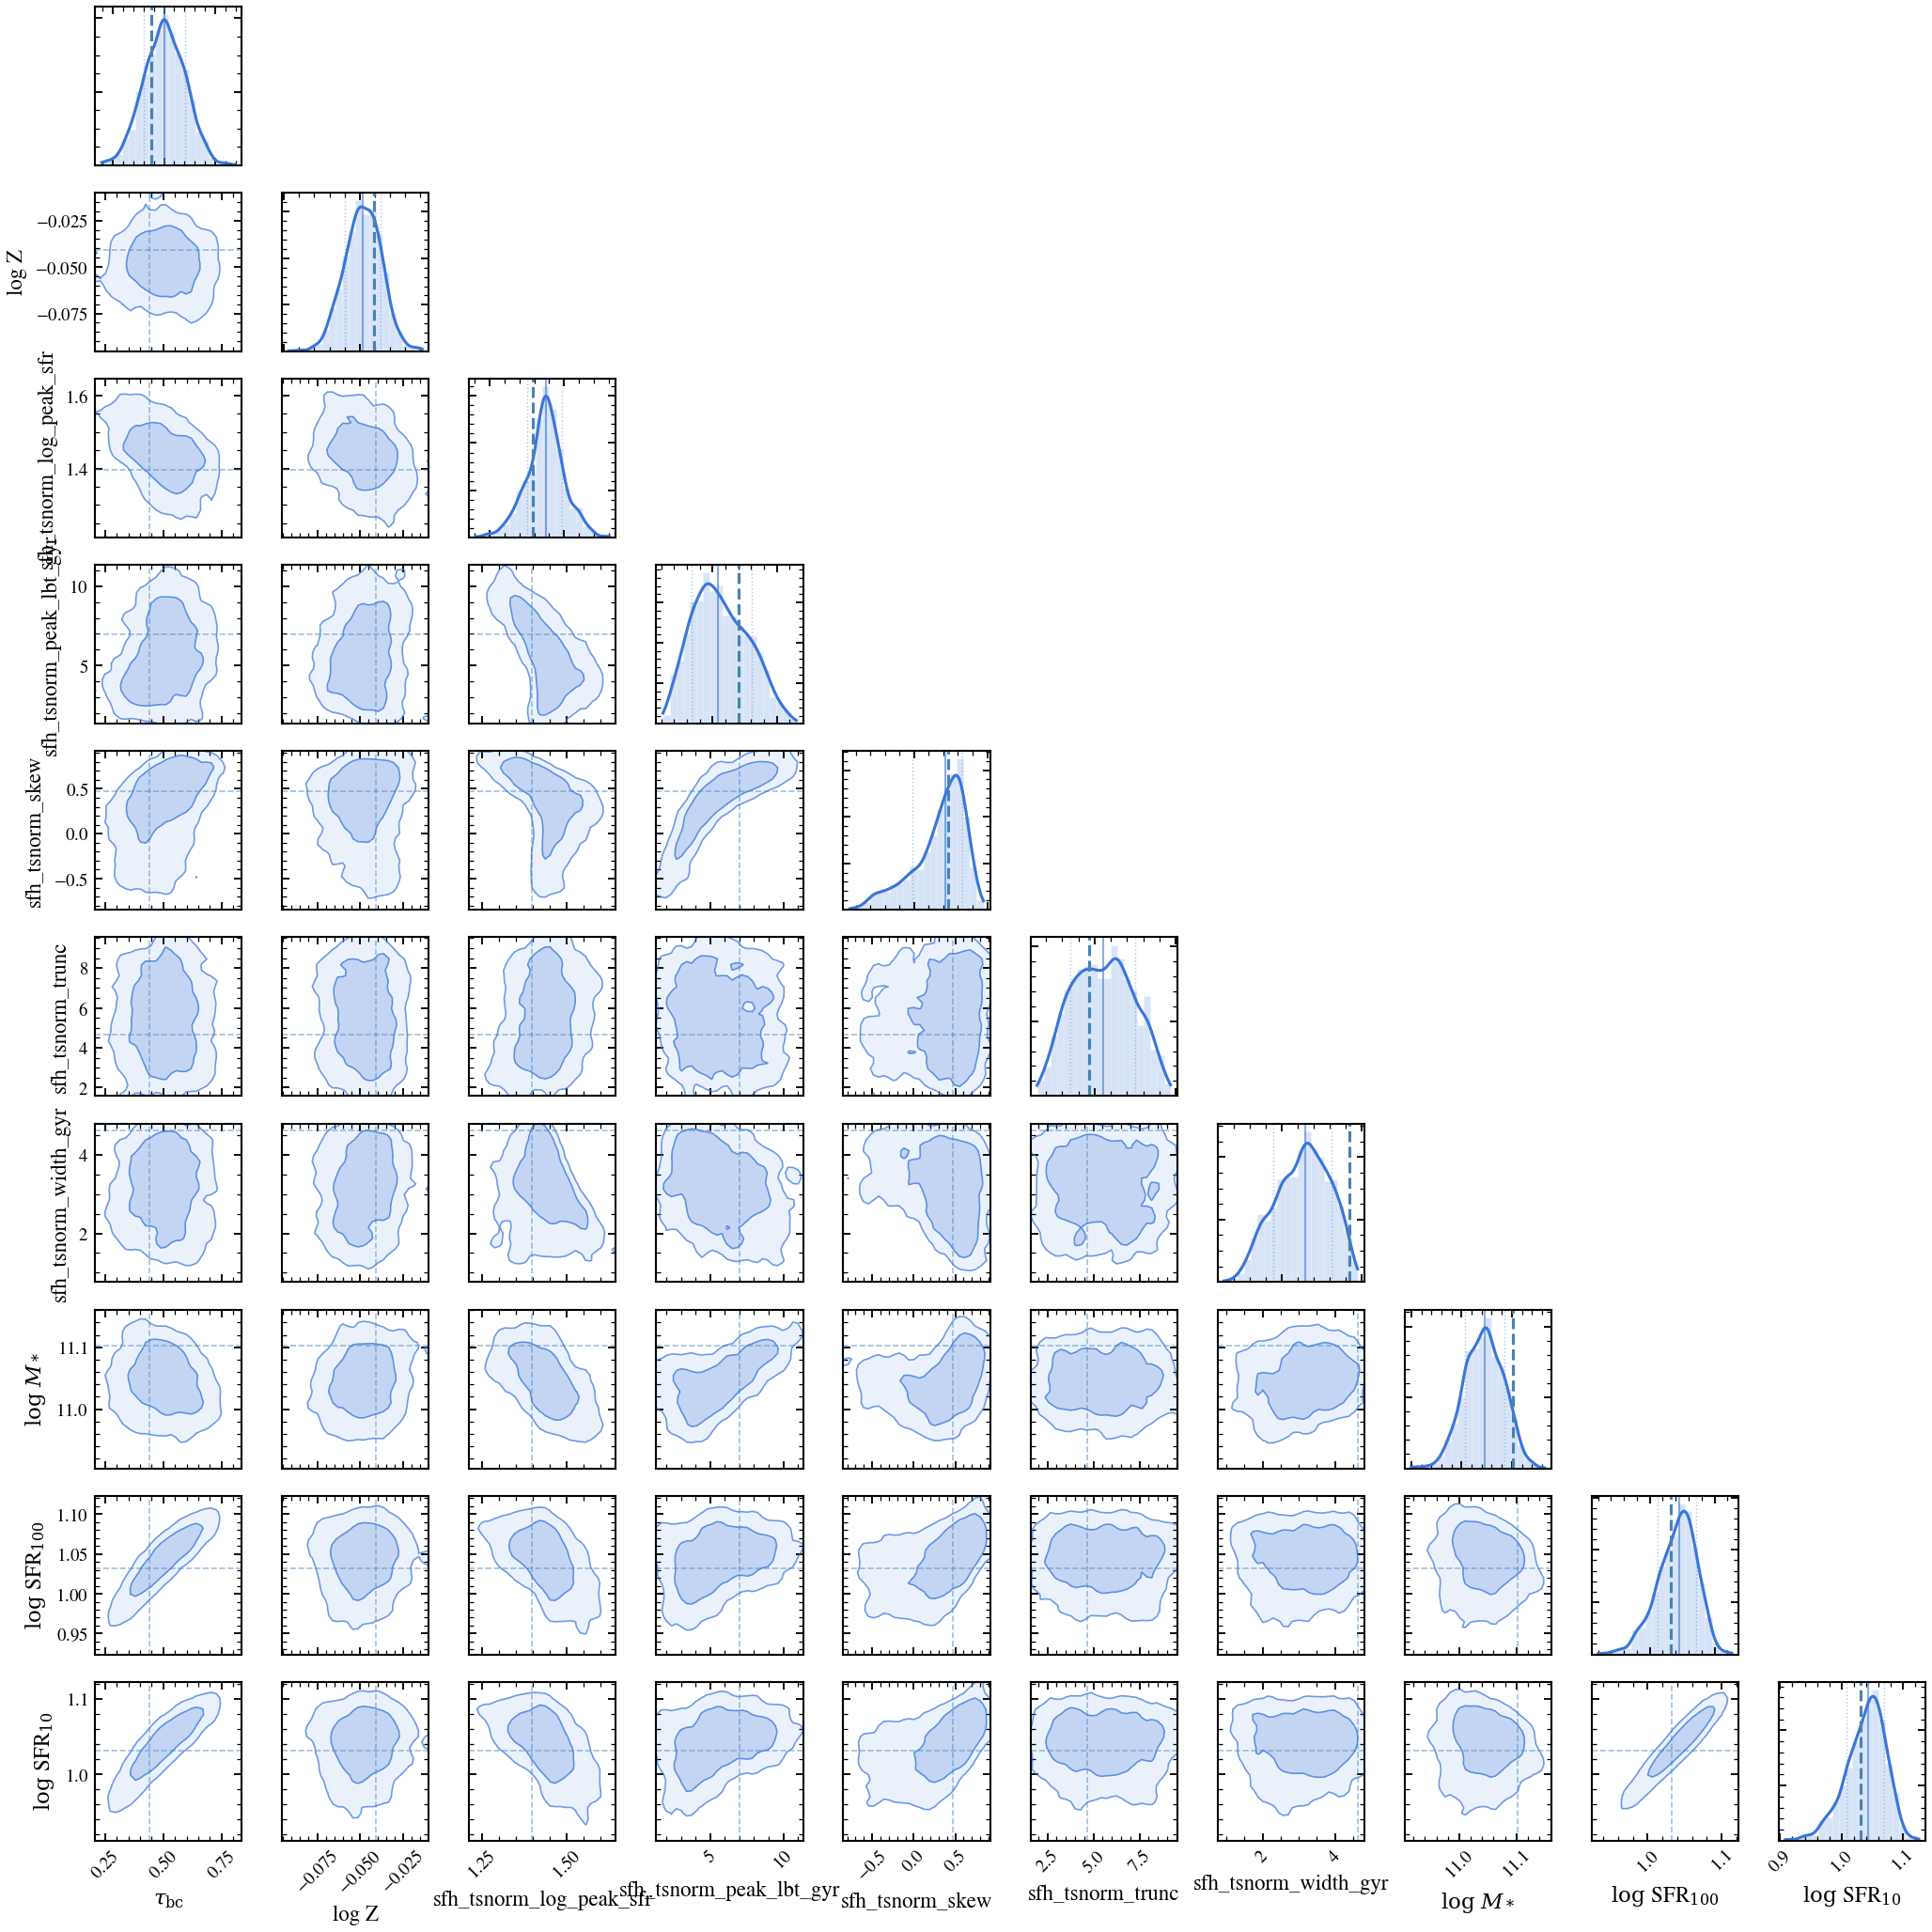

In [11]:
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "00_corner.pdf", bbox_inches="tight")